In [1]:
import torch
from torch_geometric.data import Data

print("Torch version:", torch.__version__)

x = torch.tensor([
    [1.0],
    [2.0],
    [3.0],
    [4.0],
], dtype=torch.float)

edge_index = torch.tensor([
    [0, 1, 1, 2, 2, 3],
    [1, 0, 2, 1, 3, 2],
], dtype=torch.long)

data = Data(x=x, edge_index=edge_index)

print(data)
print("Node features shape:", data.x.shape)
print("Edge index shape:", data.edge_index.shape)

c:\Users\riyat\miniconda3\envs\thesis\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Torch version: 2.10.0+cpu
Data(x=[4, 1], edge_index=[2, 6])
Node features shape: torch.Size([4, 1])
Edge index shape: torch.Size([2, 6])


In [2]:
print("Node feature matrix:")
print(data.x)

print("\nEdge index:")
print(data.edge_index)

Node feature matrix:
tensor([[1.],
        [2.],
        [3.],
        [4.]])

Edge index:
tensor([[0, 1, 1, 2, 2, 3],
        [1, 0, 2, 1, 3, 2]])


In [3]:
from torch_geometric.nn import GCNConv

conv = GCNConv(in_channels=1, out_channels=2)

out = conv(data.x, data.edge_index)

print("Output node embeddings:")
print(out)
print("Output shape:", out.shape)

Output node embeddings:
tensor([[ 0.9670, -0.4413],
        [ 1.5241, -0.6956],
        [ 2.4238, -1.1061],
        [ 2.3687, -1.0810]], grad_fn=<AddBackward0>)
Output shape: torch.Size([4, 2])


In [4]:
print("Original node features:")
for i, feat in enumerate(data.x):
    print(f"Node {i}: {feat.tolist()}")

print("\nLearned output embeddings:")
for i, emb in enumerate(out):
    print(f"Node {i}: {emb.detach().tolist()}")

Original node features:
Node 0: [1.0]
Node 1: [2.0]
Node 2: [3.0]
Node 3: [4.0]

Learned output embeddings:
Node 0: [0.9670339822769165, -0.4413275718688965]
Node 1: [1.524130940437317, -0.6955711841583252]
Node 2: [2.4237685203552246, -1.1061409711837769]
Node 3: [2.368739604949951, -1.0810272693634033]


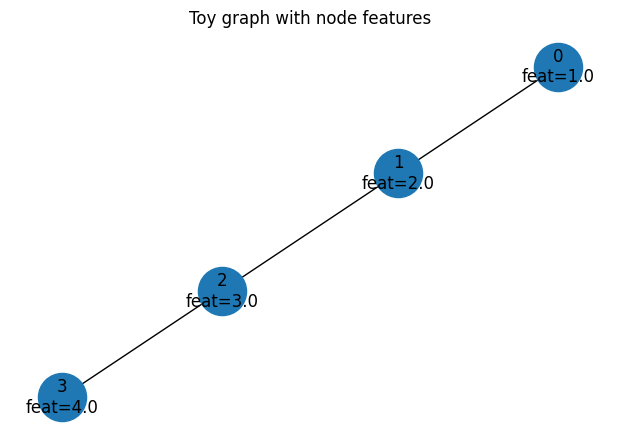

In [5]:
import networkx as nx
import matplotlib.pyplot as plt
from torch_geometric.utils import to_networkx

G_nx = to_networkx(data, to_undirected=True)

pos = nx.spring_layout(G_nx, seed=42)
labels = {i: f"{i}\nfeat={data.x[i].item()}" for i in range(data.num_nodes)}

plt.figure(figsize=(6, 4))
nx.draw(G_nx, pos, with_labels=True, labels=labels, node_size=1200)
plt.title("Toy graph with node features")
plt.show()

In [7]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

print(project_root)

c:\Users\riyat\Documents\Thesis Implementations


In [8]:
from src.graphs.graph_basics import make_grid_graph
from torch_geometric.utils import from_networkx

G_grid = make_grid_graph(4, 4)

for node in G_grid.nodes():
    G_grid.nodes[node]["x"] = [float(G_grid.degree[node])]

data_grid = from_networkx(G_grid)
data_grid.x = data_grid.x.float()

print(data_grid)
print("Node features shape:", data_grid.x.shape)
print("Edge index shape:", data_grid.edge_index.shape)

Data(x=[16, 1], edge_index=[2, 48])
Node features shape: torch.Size([16, 1])
Edge index shape: torch.Size([2, 48])


In [9]:
from torch_geometric.nn import GCNConv

conv_grid = GCNConv(in_channels=1, out_channels=2)
out_grid = conv_grid(data_grid.x, data_grid.edge_index)

print("Grid graph output embeddings:")
print(out_grid)
print("Output shape:", out_grid.shape)

Grid graph output embeddings:
tensor([[2.9438, 1.5160],
        [3.6471, 1.8782],
        [3.6471, 1.8782],
        [2.9438, 1.5160],
        [3.6471, 1.8782],
        [4.5919, 2.3648],
        [4.5919, 2.3648],
        [3.6471, 1.8782],
        [3.6471, 1.8782],
        [4.5919, 2.3648],
        [4.5919, 2.3648],
        [3.6471, 1.8782],
        [2.9438, 1.5160],
        [3.6471, 1.8782],
        [3.6471, 1.8782],
        [2.9438, 1.5160]], grad_fn=<AddBackward0>)
Output shape: torch.Size([16, 2])


In [10]:
print("Node | Degree | Embedding")
print("-" * 40)

for node in G_grid.nodes():
    degree = G_grid.degree[node]
    embedding = out_grid[node].detach().tolist()
    print(f"{node:>4} | {degree:>6} | {embedding}")

Node | Degree | Embedding
----------------------------------------
   0 |      2 | [2.943798542022705, 1.5160377025604248]
   1 |      3 | [3.6470799446105957, 1.878223180770874]
   2 |      3 | [3.6470799446105957, 1.878223180770874]
   3 |      2 | [2.943798542022705, 1.5160377025604248]
   4 |      3 | [3.6470794677734375, 1.878223180770874]
   5 |      4 | [4.591885566711426, 2.3647921085357666]
   6 |      4 | [4.591885566711426, 2.3647923469543457]
   7 |      3 | [3.6470794677734375, 1.878223180770874]
   8 |      3 | [3.6470799446105957, 1.878223180770874]
   9 |      4 | [4.591885566711426, 2.3647923469543457]
  10 |      4 | [4.591885566711426, 2.3647923469543457]
  11 |      3 | [3.6470799446105957, 1.878223180770874]
  12 |      2 | [2.943798542022705, 1.5160377025604248]
  13 |      3 | [3.6470794677734375, 1.878223180770874]
  14 |      3 | [3.6470799446105957, 1.878223180770874]
  15 |      2 | [2.943798542022705, 1.5160377025604248]


In [11]:
from src.graphs.graph_basics import make_ladder_graph

G_ladder = make_ladder_graph(6)

for node in G_ladder.nodes():
    G_ladder.nodes[node]["x"] = [float(G_ladder.degree[node])]

data_ladder = from_networkx(G_ladder)
data_ladder.x = data_ladder.x.float()

conv_ladder = GCNConv(in_channels=1, out_channels=2)
out_ladder = conv_ladder(data_ladder.x, data_ladder.edge_index)

print(data_ladder)
print("Output shape:", out_ladder.shape)

print("\nNode | Degree | Embedding")
print("-" * 40)
for node in G_ladder.nodes():
    degree = G_ladder.degree[node]
    embedding = out_ladder[node].detach().tolist()
    print(f"{node:>4} | {degree:>6} | {embedding}")

Data(x=[12, 1], edge_index=[2, 32])
Output shape: torch.Size([12, 2])

Node | Degree | Embedding
----------------------------------------
   0 |      2 | [-1.1752889156341553, 0.07161739468574524]
   1 |      3 | [-1.5108739137649536, 0.09206658601760864]
   2 |      3 | [-1.6031341552734375, 0.09768855571746826]
   3 |      3 | [-1.6031341552734375, 0.09768855571746826]
   4 |      3 | [-1.5108739137649536, 0.09206658601760864]
   5 |      2 | [-1.1752889156341553, 0.07161739468574524]
   6 |      2 | [-1.1752889156341553, 0.07161739468574524]
   7 |      3 | [-1.5108739137649536, 0.09206658601760864]
   8 |      3 | [-1.6031341552734375, 0.09768855571746826]
   9 |      3 | [-1.6031341552734375, 0.09768855571746826]
  10 |      3 | [-1.5108739137649536, 0.09206658601760864]
  11 |      2 | [-1.1752889156341553, 0.07161739468574524]


## Initial observation

A one-layer GCN was applied to small graph-family examples using node degree as the only input feature.

For the grid graph, the learned node embeddings mainly grouped nodes by structural role (corner, edge, interior), which also corresponds to node degree.

For the ladder graph, the embeddings separated not only degree-2 and degree-3 nodes, but also different positional roles among degree-3 nodes. This suggests that the GCN is already incorporating neighborhood structure through message passing.